In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_excel('SLR.xlsx')

In [8]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

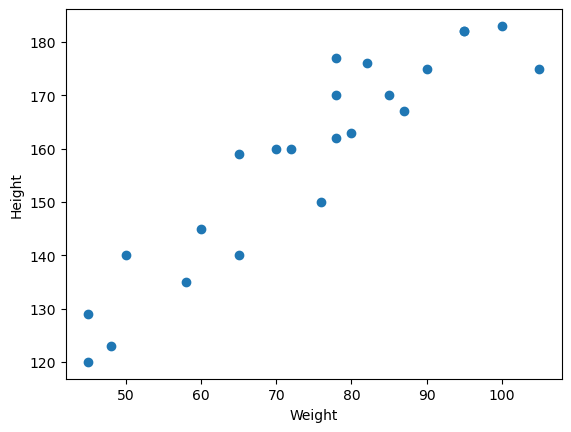

In [9]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [10]:
df.corr()

,Weight,Height
Weight,1.000000,0.925739
Height,0.925739,1.000000


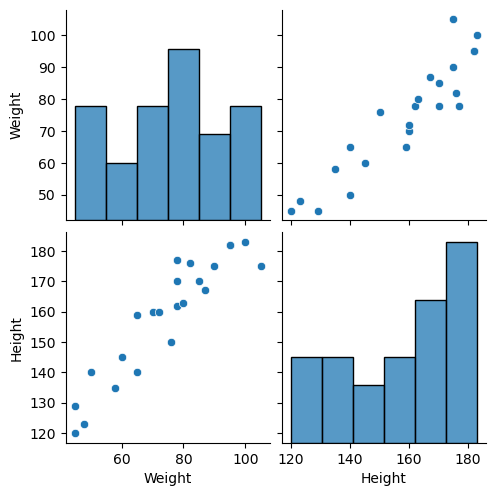

In [11]:
sns.pairplot(df)

## Independent variable should always be in Dataframe (means 2D) format.

In [14]:
#independent and dependent variable
import numpy as np
X = df[['Weight']]
np.array(X).shape

(23, 1)

In [15]:
y = df['Height']

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.25, random_state = 42)

In [18]:
X_train.shape

(17, 1)

In [19]:
#Standardization
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()


In [21]:
X_train = scaler.fit_transform(X_train)

In [22]:
X_test = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
regression = LinearRegression()
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
print('Coefficients: ', regression.coef_)
print('Intercept: ', regression.intercept_)

Coefficients:  [17.18342415]
Intercept:  156.47058823529412


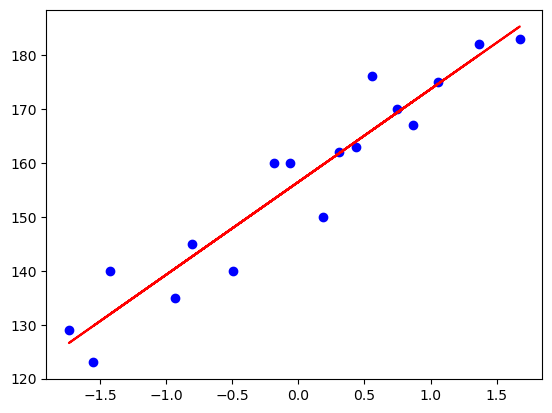

In [26]:
## Plot Training data and regression line
plt.scatter(X_train, y_train, color = 'blue')
plt.plot(X_train, regression.predict(X_train), color = 'red')

In [27]:
y_pred = regression.predict(X_test)

# Performance testing

In [28]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rsme = np.sqrt(mse)
print('MAE: ', mae)
print('MSE: ', mse)
print('RSME: ', rsme)

MAE:  9.787682434714588
MSE:  118.63589294258838
RSME:  10.892010509662043


In [30]:
score = r2_score(y_test, y_pred)
print('R2 Score: ', score)

R2 Score:  0.7273608588615907


In [32]:
# Adjusted R2 Score
adjusted_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print('Adjusted R2 Score: ', adjusted_r2)

Adjusted R2 Score:  0.6592010735769884


## OLS linear regression

In [34]:
import statsmodels.api as sm

model = sm.OLS(y_train , X_train).fit()

In [35]:
prediction = model.predict(X_test)

In [36]:
print(prediction)

[  5.33318223   5.33318223 -29.86582049  23.46600181  -8.53309157
  34.13236627]


In [37]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1927
Date:                Tue, 09 Jun 2026   Prob (F-statistic):                       0.667
Time:                        14:33:11   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [39]:
# Prediction of new data

#Without Scaling
n1 = regression.predict([[70]])
print(n1)

[1359.31027889]


In [40]:
#With Scaling
n2 = regression.predict(scaler.transform([[70]]))
print(n2)

[153.2706789]


c:\Users\iamsi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
